### main.py через jupyter

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ml_pipeline.config import config
from ml_pipeline.utils import set_seed

In [2]:
set_seed(config.general.seed)

In [3]:
full_df = pd.read_csv(config.paths.train, index_col="PassengerId")
full_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
from ml_pipeline.pipeline import MLPipeline

pipeline = MLPipeline(config)

In [5]:
pipeline.run(train_df=full_df)

0. dummy
model_params={'strategy': 'most_frequent'}
Fold 1/5  accuracy: 0.6145
Fold 2/5  accuracy: 0.6180
Fold 3/5  accuracy: 0.6180
Fold 4/5  accuracy: 0.6180
Fold 5/5  accuracy: 0.6124
-> Best fold: 2, CV accuracy: 0.6162, std: 0.0023

1. logistic_regression
model_params={'l1_ratio': 0, 'solver': 'lbfgs', 'max_iter': 500}
Fold 1/5  accuracy: 0.7765
Fold 2/5  accuracy: 0.8146
Fold 3/5  accuracy: 0.7753
Fold 4/5  accuracy: 0.8146
Fold 5/5  accuracy: 0.8315
-> Best fold: 5, CV accuracy: 0.8025, std: 0.0226

2. knn
model_params={'n_neighbors': 3}
Fold 1/5  accuracy: 0.7989
Fold 2/5  accuracy: 0.7697
Fold 3/5  accuracy: 0.6966
Fold 4/5  accuracy: 0.8090
Fold 5/5  accuracy: 0.8090
-> Best fold: 4, CV accuracy: 0.7766, std: 0.0425

3. decision_tree
model_params={'random_state': 42, 'min_samples_leaf': 4}
Fold 1/5  accuracy: 0.8045
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.8202
Fold 4/5  accuracy: 0.8371
Fold 5/5  accuracy: 0.7978
-> Best fold: 4, CV accuracy: 0.8115, std: 0.0152

4. 

In [6]:
full_test_df = pd.read_csv(config.paths.test, index_col="PassengerId")
pipeline.predict(test_df=full_test_df)

In [19]:
def experiment_boxplot(experiments: list):
    data = []

    for item in experiments:
        data.append([x["score"] for x in item["fold_data"]])

    plt.boxplot(data)
    plt.show()

### Логистическая регрессия

Посмотрим, как влияет коэффициент L1 регуляризации на метрику. Видимо, влияние малое

Для параметров ("l1_ratio": 0, "solver": "lbfgs", "max_iter": 500)

- Лучший фолд: 0.8315
- Public LB: 0.76794

In [ ]:
config_elastic = config.copy()

to_train = []

for i in range(0, 10):
    to_train.append(
        {
            "model": "logistic_regression",
            "params": {"l1_ratio": i * 0.1, "solver": "saga", "max_iter": 500},
        }
    )

config_elastic.experiment.to_train = to_train

elastic_pipeline = MLPipeline(config_elastic)

elastic_pipeline.run(train_df=full_df)

0. logistic_regression
model_params={'l1_ratio': 0.0, 'solver': 'saga', 'max_iter': 500}
Fold 1/5  accuracy: 0.7709
Fold 2/5  accuracy: 0.8146
Fold 3/5  accuracy: 0.7753
Fold 4/5  accuracy: 0.8146
Fold 5/5  accuracy: 0.8315
-> Best fold: 5, CV accuracy: 0.8014, std: 0.0239

1. logistic_regression
model_params={'l1_ratio': 0.1, 'solver': 'saga', 'max_iter': 500}
Fold 1/5  accuracy: 0.7765
Fold 2/5  accuracy: 0.8146
Fold 3/5  accuracy: 0.7753
Fold 4/5  accuracy: 0.8146
Fold 5/5  accuracy: 0.8315
-> Best fold: 5, CV accuracy: 0.8025, std: 0.0226

2. logistic_regression
model_params={'l1_ratio': 0.2, 'solver': 'saga', 'max_iter': 500}
Fold 1/5  accuracy: 0.7765
Fold 2/5  accuracy: 0.8146
Fold 3/5  accuracy: 0.7753
Fold 4/5  accuracy: 0.8146
Fold 5/5  accuracy: 0.8315
-> Best fold: 5, CV accuracy: 0.8025, std: 0.0226

3. logistic_regression
model_params={'l1_ratio': 0.30000000000000004, 'solver': 'saga', 'max_iter': 500}
Fold 1/5  accuracy: 0.7765
Fold 2/5  accuracy: 0.8146
Fold 3/5  accura

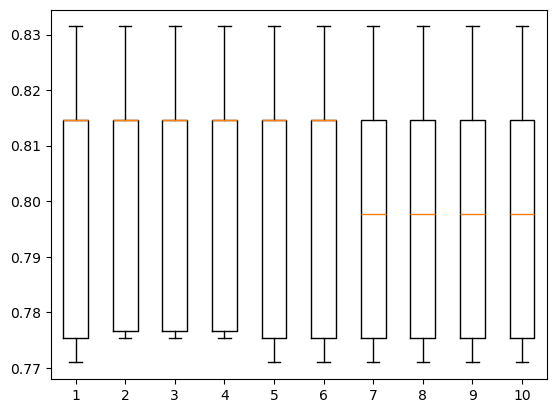

In [20]:
experiment_boxplot(elastic_pipeline.experiment_data)

###  KNN

Посмотрим, как меняется метрика в зависимости от количества соседей (k)

По графику вроде бы лучшее кол-во соседей = 7

- Лучший фолд (k=7): 0.8315
- Public LB (k=7): 0.74162

In [18]:
config_knn = config.copy()

to_train = []

for i in range(1, 10):
    to_train.append(
        {
            "model": "knn",
            "params": {"n_neighbors": i},
        }
    )

config_knn.experiment.to_train = to_train

pipeline_knn = MLPipeline(config_knn)

pipeline_knn.run(train_df=full_df)

0. knn
model_params={'n_neighbors': 1}
Fold 1/5  accuracy: 0.7821
Fold 2/5  accuracy: 0.7303
Fold 3/5  accuracy: 0.6854
Fold 4/5  accuracy: 0.7921
Fold 5/5  accuracy: 0.7640
-> Best fold: 4, CV accuracy: 0.7508, std: 0.0389

1. knn
model_params={'n_neighbors': 2}
Fold 1/5  accuracy: 0.7709
Fold 2/5  accuracy: 0.7247
Fold 3/5  accuracy: 0.7303
Fold 4/5  accuracy: 0.8202
Fold 5/5  accuracy: 0.7303
-> Best fold: 4, CV accuracy: 0.7553, std: 0.0364

2. knn
model_params={'n_neighbors': 3}
Fold 1/5  accuracy: 0.7989
Fold 2/5  accuracy: 0.7697
Fold 3/5  accuracy: 0.6966
Fold 4/5  accuracy: 0.8090
Fold 5/5  accuracy: 0.8090
-> Best fold: 4, CV accuracy: 0.7766, std: 0.0425

3. knn
model_params={'n_neighbors': 4}
Fold 1/5  accuracy: 0.8045
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.7416
Fold 4/5  accuracy: 0.8371
Fold 5/5  accuracy: 0.7921
-> Best fold: 4, CV accuracy: 0.7946, std: 0.0308

4. knn
model_params={'n_neighbors': 5}
Fold 1/5  accuracy: 0.7933
Fold 2/5  accuracy: 0.8202
Fold 3/

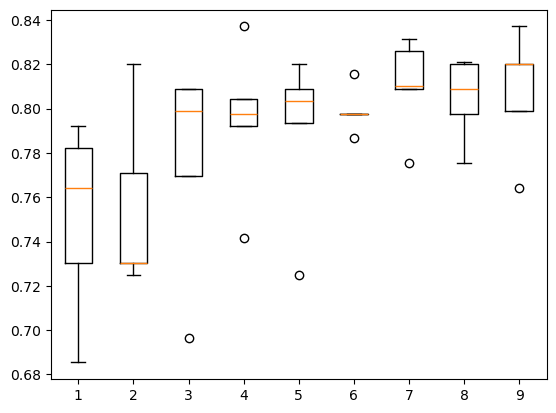

In [21]:
experiment_boxplot(pipeline_knn.experiment_data)

### Дерево

Посмотрим, можно ли регуляризовывать дерево минимальным кол-вом объектов в листе

(мин. 4 объекта в листе)
- Лучший фолд: 0.8371
- Public LB: 0.75837

Хуже, чем логрег: Возможно, дерево переобучилось на трейне

In [26]:
config_tree = config.copy()

to_train = []

for i in range(1, 8):
    to_train.append(
        {
            "model": "decision_tree",
            "params": {"min_samples_leaf": i},
        }
    )

config_tree.experiment.to_train = to_train

pipeline_tree = MLPipeline(config_tree)

pipeline_tree.run(train_df=full_df)

0. decision_tree
model_params={'random_state': 42, 'min_samples_leaf': 1}
Fold 1/5  accuracy: 0.8380
Fold 2/5  accuracy: 0.8034
Fold 3/5  accuracy: 0.7640
Fold 4/5  accuracy: 0.7921
Fold 5/5  accuracy: 0.7865
-> Best fold: 1, CV accuracy: 0.7968, std: 0.0242

1. decision_tree
model_params={'random_state': 42, 'min_samples_leaf': 2}
Fold 1/5  accuracy: 0.8101
Fold 2/5  accuracy: 0.8034
Fold 3/5  accuracy: 0.7865
Fold 4/5  accuracy: 0.8034
Fold 5/5  accuracy: 0.7921
-> Best fold: 1, CV accuracy: 0.7991, std: 0.0085

2. decision_tree
model_params={'random_state': 42, 'min_samples_leaf': 3}
Fold 1/5  accuracy: 0.8156
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.8034
Fold 4/5  accuracy: 0.8202
Fold 5/5  accuracy: 0.7809
-> Best fold: 4, CV accuracy: 0.8036, std: 0.0139

3. decision_tree
model_params={'random_state': 42, 'min_samples_leaf': 4}
Fold 1/5  accuracy: 0.8045
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.8202
Fold 4/5  accuracy: 0.8371
Fold 5/5  accuracy: 0.7978
-> Best fol

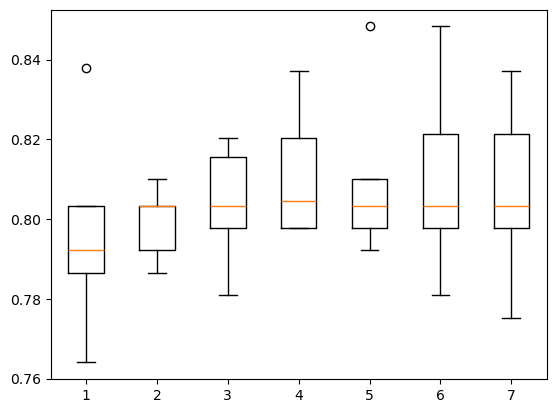

In [27]:
experiment_boxplot(pipeline_tree.experiment_data)

### Случайный лес

Посмотрим, зависит ли метрика от кол-ва деревьев

700 деревьев
- Лучший фолд: 0.8371
- Public LB: 0.79186

In [28]:
config_rf = config.copy()

to_train = []

for i in range(1, 8):
    to_train.append(
        {
            "model": "random_forest",
            "params": {"n_estimators": i * 100},
        }
    )


config_rf.experiment.to_train = to_train

pipeline_rf = MLPipeline(config_rf)

pipeline_rf.run(train_df=full_df)

0. random_forest
model_params={'n_estimators': 100, 'max_depth': 3, 'random_state': 42}
Fold 1/5  accuracy: 0.8101
Fold 2/5  accuracy: 0.8034
Fold 3/5  accuracy: 0.7921
Fold 4/5  accuracy: 0.8202
Fold 5/5  accuracy: 0.8315
-> Best fold: 5, CV accuracy: 0.8114, std: 0.0135

1. random_forest
model_params={'n_estimators': 200, 'max_depth': 3, 'random_state': 42}
Fold 1/5  accuracy: 0.8156
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.8034
Fold 4/5  accuracy: 0.8202
Fold 5/5  accuracy: 0.8371
-> Best fold: 5, CV accuracy: 0.8148, std: 0.0138

2. random_forest
model_params={'n_estimators': 300, 'max_depth': 3, 'random_state': 42}
Fold 1/5  accuracy: 0.7989
Fold 2/5  accuracy: 0.8146
Fold 3/5  accuracy: 0.8034
Fold 4/5  accuracy: 0.8315
Fold 5/5  accuracy: 0.8371
-> Best fold: 5, CV accuracy: 0.8171, std: 0.0150

3. random_forest
model_params={'n_estimators': 400, 'max_depth': 3, 'random_state': 42}
Fold 1/5  accuracy: 0.8045
Fold 2/5  accuracy: 0.8146
Fold 3/5  accuracy: 0.8034
Fold 4/5 

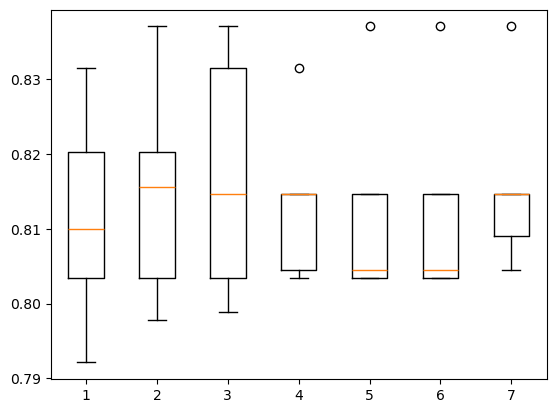

In [29]:
experiment_boxplot(pipeline_rf.experiment_data)